## CLIP Setup & Song Embedding Precomputation

**Objective:** Install and configure OpenAI CLIP, demonstrate how the shared image-text embedding space works, then batch-encode all 61,670 cleaned Spotify tracks into 512-dimensional text embeddings for downstream similarity search.

**Key Operations:**
* **CLIP Setup:** Install the model and verify the shared embedding space with a toy similarity demo.
* **Text Embedding:** Encode each song's `clip_metadata` string into a 512-d vector using the CLIP text encoder.
* **Persistence:** Save the full embedding matrix (`song_embeddings.npy`) and a row-aligned index (`song_index.csv`) so downstream notebooks can load them without re-encoding.
* **Sanity Check:** Query the embedding matrix with a natural-language vibe phrase and verify that musically plausible songs surface at the top.

In [4]:
!pip install git+https://github.com/openai/CLIP.git ftfy regex tqdm --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


---
### 1. Load the cleaned spotify dataset

The cleaned CSV was produced by `01_DataCleaning.ipynb` and lives at `data/spotify_cleaned_final.csv`.

In [6]:
import os
import pandas as pd

CSV_PATH = '../data/spotify_cleaned_final.csv'

df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} tracks with {df.shape[1]} columns.")
print(f"\nSample clip_metadata entries:")
for text in df['clip_metadata'].sample(3, random_state=42):
    print(f"  * {text}")

Loaded 61,670 tracks with 23 columns.

Sample clip_metadata entries:
  * A track titled '20-CRY-' by Miliyah. Genres: anime. Mood and sound: mixed style.
  * A track titled 'Sembrador De Amor' by Joan Sebastian. Genres: r-n-b. Mood and sound: happy and uplifting.
  * A track titled 'Snow & Sand' by j'san;Epektase. Genres: chill. Mood and sound: melancholic and sad, very danceable, instrumental.


---
### 2. Load CLIP and understand the shared embedding space

#### How CLIP Works

CLIP (Contrastive Language-Image Pre-Training) was trained by OpenAI on **400 million image-text pairs** scraped from the internet. The training objective — contrastive learning — forces:

- Matching image-text pairs → **close** in embedding space  
- Non-matching pairs → **far apart** in embedding space

This produces two encoders that project into the **same 512-dimensional vector space**:

```
Image Encoder (ViT-B/32)  →  512-d vector  ┐
                                           ├─ cosine similarity → [−1, 1]
Text Encoder (Transformer) →  512-d vector ┘
```

For our project: we encode the **user's image** with the image encoder and each **song description** with the text encoder. Because both live in the same space, cosine similarity directly measures how well a song's vibe matches the image's vibe — no additional training required.

> **Why this works without training:** A photo of a cozy coffee shop and the text *"a warm acoustic song for a quiet afternoon"* both activated similar neurons in CLIP's training data. They end up nearby in the shared space.

In [7]:
import clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

model, preprocess = clip.load("ViT-B/32", device=device)
model.eval()

print(f"\nCLIP model architecture: ViT-B/32")
print(f"Image input resolution : {model.visual.input_resolution}px")
print(f"Max token context length: {model.context_length} tokens")
print(f"Vocabulary size         : {model.vocab_size:,}")
print(f"Embedding dimension     : {model.visual.output_dim}")

Device: cpu


100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 88.3MiB/s]



CLIP model architecture: ViT-B/32
Image input resolution : 224px
Max token context length: 77 tokens
Vocabulary size         : 49,408
Embedding dimension     : 512


---
## 3. Demonstration: The Shared Embedding Space

Before encoding 61K songs, let's verify that the text encoder actually captures semantic similarity. We'll encode several vibe phrases and compute a pairwise cosine similarity matrix.

**Expected behavior:** Phrases describing the same vibe (e.g., two "cozy" phrases) should score near 1.0; phrases with opposite vibes should score near 0 or below.

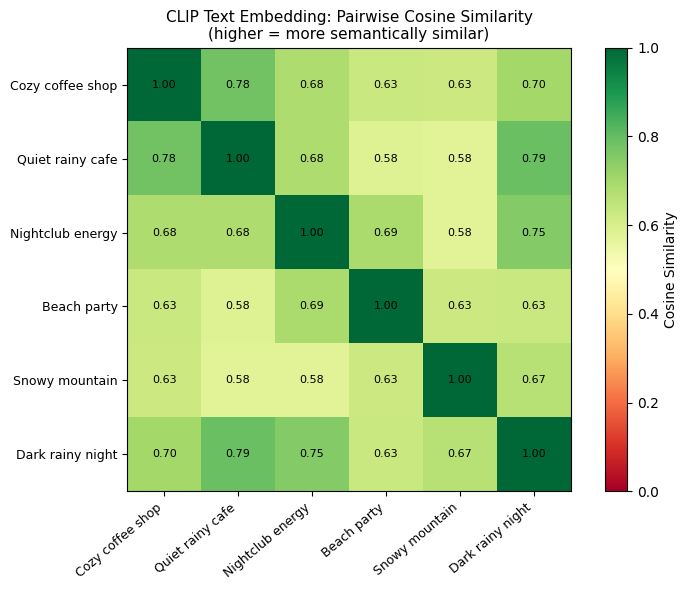

In [9]:
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

vibe_phrases = [
    "a cozy coffee shop with soft warm lighting",
    "a quiet cafe on a rainy afternoon with jazz",
    "a high-energy nightclub with bass and dancing",
    "an energetic beach party at sunset",
    "a peaceful snowy mountain trail at dawn",
    "a dark melancholic rainy night in the city",
]

with torch.no_grad():
    tokens = clip.tokenize(vibe_phrases, truncate=True).to(device)
    text_features = model.encode_text(tokens)
    text_features = F.normalize(text_features, dim=-1)

sim_matrix = (text_features @ text_features.T).cpu().numpy()

# Visualize as a heatmap
short_labels = [
    "Cozy coffee shop",
    "Quiet rainy cafe",
    "Nightclub energy",
    "Beach party",
    "Snowy mountain",
    "Dark rainy night",
]

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(sim_matrix, vmin=0, vmax=1, cmap='RdYlGn')
plt.colorbar(im, ax=ax, label='Cosine Similarity')

ax.set_xticks(range(len(short_labels)))
ax.set_yticks(range(len(short_labels)))
ax.set_xticklabels(short_labels, rotation=40, ha='right', fontsize=9)
ax.set_yticklabels(short_labels, fontsize=9)

for i in range(len(short_labels)):
    for j in range(len(short_labels)):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha='center', va='center', fontsize=8, color='black')

ax.set_title("CLIP Text Embedding: Pairwise Cosine Similarity\n(higher = more semantically similar)", fontsize=11)
plt.tight_layout()
plt.show()


**Observations:**

- **Cozy coffee shop ↔ Quiet rainy cafe (0.78):** highest off-diagonal score. Both are calm, intimate indoor settings — correctly identified as the most similar pair.
- **Dark rainy night ↔ Quiet rainy cafe (0.79):** also high, as both share a rainy, quiet, and moody atmosphere.
- **Nightclub energy ↔ Beach party (0.69):** correctly grouped together as the two high-energy, social scenes.
- **Snowy mountain** has the lowest similarities across the board (0.58–0.67), correctly reflecting it as the most distinct vibe with no strong semantic overlap with the others.
- **Nightclub energy ↔ Dark rainy night (0.75):** unexpectedly high. These feel like opposite vibes, but both phrases contain "night" and urban imagery, causing surface-level overlap in text-only embeddings. This limitation resolves naturally when using real images in notebook 03 — visual features (bright/crowded vs. dark/empty street) separate them clearly.

---
### 4. Batch encode all song descriptions

We now run the CLIP text encoder over all 61,670 `clip_metadata` strings. Each string is tokenized (max 77 tokens; longer strings are truncated), encoded, and L2-normalized. The result is a matrix of shape `[61670, 512]`.

In [10]:
from tqdm import tqdm

BATCH_SIZE = 256

texts = df['clip_metadata'].tolist()
all_embeddings = []

print(f"Encoding {len(texts):,} tracks in batches of {BATCH_SIZE}...")

with torch.no_grad():
    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc="Encoding songs"):
        batch = texts[i : i + BATCH_SIZE]
        tokens = clip.tokenize(batch, truncate=True).to(device)
        embeddings = model.encode_text(tokens)
        embeddings = F.normalize(embeddings, dim=-1)
        all_embeddings.append(embeddings.cpu().numpy())

song_embeddings = np.vstack(all_embeddings)

print(f"\nEmbedding matrix shape : {song_embeddings.shape}")
print(f"Dtype                  : {song_embeddings.dtype}")
print(f"Memory usage           : {song_embeddings.nbytes / 1e6:.1f} MB")
print(f"\nEach row is a 512-d unit vector (L2 norm ~ 1.0).")
print(f"Sample norms: {np.linalg.norm(song_embeddings[:5], axis=1).round(4)}")

Encoding 61,670 tracks in batches of 256...


Encoding songs: 100%|██████████| 241/241 [14:26<00:00,  3.59s/it]


Embedding matrix shape : (61670, 512)
Dtype                  : float32
Memory usage           : 126.3 MB

Each row is a 512-d unit vector (L2 norm ~ 1.0).
Sample norms: [1. 1. 1. 1. 1.]


Two files are saved:
- `song_embeddings.npy` — the full `[N, 512]` float32 matrix
- `song_index.csv` — track metadata where row `i` corresponds to `song_embeddings[i]`

In [11]:
OUTPUT_DIR = '../data'
os.makedirs(OUTPUT_DIR, exist_ok=True)

EMBEDDINGS_PATH = os.path.join(OUTPUT_DIR, 'song_embeddings.npy')
INDEX_PATH      = os.path.join(OUTPUT_DIR, 'song_index.csv')

np.save(EMBEDDINGS_PATH, song_embeddings)

index_df = df[['track_id', 'track_name', 'artists', 'popularity', 'merged_genres', 'clip_metadata']].copy()
index_df = index_df.reset_index(drop=True)
index_df.to_csv(INDEX_PATH, index=False)

print(f"Saved embedding matrix → {EMBEDDINGS_PATH}")
print(f"Saved song index       → {INDEX_PATH}")
print(f"\nIndex shape  : {index_df.shape}")
print(f"Matrix shape : {song_embeddings.shape}")
print(f"Row 0 check  : index[0] = '{index_df.iloc[0]['track_name']}', "
      f"embedding[0] norm = {np.linalg.norm(song_embeddings[0]):.4f}")

Saved embedding matrix → ../data/song_embeddings.npy
Saved song index       → ../data/song_index.csv

Index shape  : (61670, 6)
Matrix shape : (61670, 512)
Row 0 check  : index[0] = 'Unholy (feat. Kim Petras)', embedding[0] norm = 1.0000


---
### 5. Sanity check: natural-language vibe query

This cell simulates what the full system does at query time — except here we're using a **text query** instead of an image. (The image encoder will be wired in notebook 03.)

We encode a vibe phrase with the same text encoder, compute cosine similarity against all 61,670 song embeddings, and print the top results. If CLIP's shared space is working correctly, the top songs should semantically match the query's mood.

In [12]:
def query_songs(query_text, top_k=10):
    """Return the top-K songs whose clip_metadata best matches a vibe phrase."""
    with torch.no_grad():
        tokens = clip.tokenize([query_text], truncate=True).to(device)
        q_emb  = model.encode_text(tokens)
        q_emb  = F.normalize(q_emb, dim=-1).cpu().numpy()

    sims    = (song_embeddings @ q_emb.T).squeeze()   # shape: [N]
    top_idx = np.argsort(sims)[::-1][:top_k]

    results = []
    for rank, idx in enumerate(top_idx):
        row = index_df.iloc[idx]
        results.append({
            'rank'         : rank + 1,
            'similarity'   : round(float(sims[idx]), 4),
            'track_name'   : row['track_name'],
            'artists'      : row['artists'],
            'genres'       : row['merged_genres'],
            'popularity'   : row['popularity'],
        })
    return pd.DataFrame(results)


# ── Test 1: Coffee shop / studying vibe ──────────────────────────────────────
query1 = "studying at a cozy coffee shop with warm lighting and soft music"
print(f"Query: '{query1}'\n")
print(query_songs(query1).to_string(index=False))

print("\n" + "─" * 70 + "\n")

# ── Test 2: Winter / snow vibe ───────────────────────────────────────────────
query2 = "walking through a quiet snow-covered street on a winter evening"
print(f"Query: '{query2}'\n")
print(query_songs(query2).to_string(index=False))

Query: 'studying at a cozy coffee shop with warm lighting and soft music'

 rank  similarity                       track_name              artists                     genres  popularity
    1      0.6365 Falling in Love at a Coffee Shop          Landon Pigg                   acoustic          58
    2      0.6172                        Jazz Bars          Dusty Decks                      study          41
    3      0.6155                  Coffe Cup Spots Breakfast For Brunch                      study          24
    4      0.6064                   Fire and Light              Actress club, world-music, ambient          57
    5      0.6043                       old coffee             wavcrush                      study          48
    6      0.5994                        Lazy Days           My Ol' Man                      study          36
    7      0.5992                One Nap At a Time Breakfast For Brunch                      study          44
    8      0.5991                    

In [13]:
# ── Test 3: High-energy party vibe ──────────────────────────────────────────
query3 = "a high-energy dance party with flashing lights and a big crowd"
print(f"Query: '{query3}'\n")
print(query_songs(query3).to_string(index=False))

print("\n" + "─" * 70 + "\n")

# ── Test 4: Melancholic / rainy night vibe ───────────────────────────────────
query4 = "a rainy night alone in the city, feeling nostalgic and a little sad"
print(f"Query: '{query4}'\n")
print(query_songs(query4).to_string(index=False))

Query: 'a high-energy dance party with flashing lights and a big crowd'

 rank  similarity                                               track_name                     artists     genres  popularity
    1      0.7902                                          Walking Walking          Super Simple Songs   children          54
    2      0.7881                                                    Sleep                One True God       club          42
    3      0.7878 I'm Not Gonna Teach Your Boyfriend How to Dance with You                  Black Kids    j-dance          32
    4      0.7826                                      Walking in the City                 Play School   children          33
    5      0.7812                                              Pray For It                One True God       club          40
    6      0.7800                                             Lightbringer                Far Too Loud  breakbeat          33
    7      0.7793                            

---
### Summary

| Step | Output |
|------|--------|
| CLIP model loaded (`ViT-B/32`) | 512-d shared embedding space confirmed |
| Shared space demo | Pairwise vibe similarity heatmap |
| Batch text encoding (61,670 tracks) | `data/song_embeddings.npy` (shape: `[61670, 512]`) |
| Row-aligned metadata | `data/song_index.csv` |
| Sanity queries | Top-K songs retrieved by vibe phrase |

### Architecture so far

```
[clip_metadata strings]  ──► CLIP Text Encoder ──► song_embeddings.npy
                                                         │
                                                         ▼
[User image]  ──► CLIP Image Encoder ──► image_emb ──► cosine sim ──► top-K songs
```

### Next: `03_vibe_mapping.ipynb`

- Wire in the **CLIP image encoder** (instead of text queries)
- Define a **vibe taxonomy** (12 scene categories mapped to compatible Spotify genres)
- Build the full `image → vibe label → genre filter → cosine similarity → playlist` pipeline
- Test end-to-end on real photos (coffee shop, snow street, beach, party, etc.)